# XL-Sum Model Evaluation Pipeline

Bu notebook, Drive'daki yerel modelleri XL-Sum `test` split'i üzerinde değerlendirir ve raporlanabilir çıktılar üretir.

Kapsam:
- Tekil İngilizce modeller: sadece `en` XL-Sum test seti.
- Çok dilli modeller: seçilen dillerin XL-Sum'da mevcut olan test setleri.
- Klasik metrikler: ROUGE-1/2/L, BLEU, METEOR-lite.
- İnsan-merkezli Section 2.4 proxy skorları: coherence, accuracy, clarity, relevance, efficiency.
- Çıktılar: detay CSV/JSONL, model-dil özet CSV, model makro özet CSV, Excel workbook, Markdown rapor ve grafikler.

Veri sızıntısı önlemi: `XLSUM_SPLIT` varsayılanı `test`; notebook `train` split'i ile çalışmayı bilerek engeller.

In [ ]:
# Colab dependency setup
!pip -q install -U \
  "transformers==4.44.2" \
  "datasets==2.21.0" \
  "evaluate==0.4.2" \
  "sacrebleu==2.4.3" \
  "sentencepiece==0.2.0" \
  "protobuf>=4.25.3" \
  "accelerate==0.34.2" \
  "rouge-score==0.1.2" \
  "pandas>=2.0.0" \
  "openpyxl>=3.1.2" \
  "matplotlib>=3.7.0" \
  "seaborn>=0.13.0" \
  "tqdm>=4.66.0" \
  "tabulate>=0.9.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 36.1 MB/s eta 0:00:00
 

In [ ]:
from __future__ import annotations

import gc
import json
import math
import os
import re
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import sacrebleu
import torch
from datasets import get_dataset_config_names, load_dataset
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception as exc:
    plt = None
    sns = None
    print(f"Plot libraries unavailable: {exc}")

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print(f"Google Drive mount skipped. If you are in Colab, mount Drive manually. Detail: {exc}")

Mounted at /content/drive


In [ ]:
# =========================================================
# CONFIG
# =========================================================

# Drive'da proje klasorunuz farkliysa bu yolu degistirin.
DRIVE_PROJECT_ROOT = Path("/content/drive/MyDrive/inf494_projet")
MODEL_ROOT = DRIVE_PROJECT_ROOT / "models"
OUTPUT_ROOT = DRIVE_PROJECT_ROOT / "evaluation" / "xlsum_eval_runs"
HF_CACHE_DIR = DRIVE_PROJECT_ROOT / ".cache" / "huggingface" / "datasets"

RUN_NAME = f"xlsum_eval_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
RUN_DIR = OUTPUT_ROOT / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Data leakage olmamasi icin train split'i engellenir.
XLSUM_SPLIT = "test"
if XLSUM_SPLIT.strip().lower() == "train":
    raise ValueError("Use validation/test for evaluation. Train split is blocked to avoid leakage.")

SELECTED_LANGS = [
    "en", "tr", "fr", "de", "es", "it", "ru", "ar", "hi", "zh", "ja", "ko", "nl", "ro", "vi"
]

# Hızlı smoke test icin 10-50 yapin. Nihai A100 kosusu icin None kullanabilirsiniz.
MAX_SAMPLES_PER_LANG: Optional[int] = None
LANG_SAMPLE_OVERRIDES: Dict[str, Optional[int]] = {}

SEED = 42
BATCH_SIZE = 8
MAX_SOURCE_TOKENS = 512
LOCAL_FILES_ONLY = True
INCLUDE_TITLE_IN_INPUT = False
SAVE_GENERATED_SUMMARIES = True
REQUIRE_ALL_SELECTED_LANGS_IN_XLSUM = False

# Torch memory/performance
USE_FP16_ON_CUDA = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print({"device": DEVICE, "run_dir": str(RUN_DIR)})

MODEL_SPECS = [
    {"key": "bart_large_cnn", "path": MODEL_ROOT / "bart_large-cnn", "scope": "english", "family": "bart", "langs": ["en"]},
    {"key": "bart_base_cnn", "path": MODEL_ROOT / "bart_base-cnn", "scope": "english", "family": "bart", "langs": ["en"]},
    {"key": "bart_reuters", "path": MODEL_ROOT / "bart_base-reuters" / "bart-reuters-best", "scope": "english", "family": "bart", "langs": ["en"]},
    {"key": "mbart50_xlsum", "path": MODEL_ROOT / "mbart50-xlsum", "scope": "multilingual", "family": "mbart", "langs": "auto"},
    {"key": "mbart-xlsum-2", "path": MODEL_ROOT / "mbart-xlsum-2", "scope": "multilingual", "family": "mbart", "langs": "auto"},
    {"key": "mt5-xlsum", "path": MODEL_ROOT / "mt5-xlsum", "scope": "multilingual", "family": "mt5", "langs": "auto"},
]

# Projedeki 15 dilin model/dataset eslesmeleri.
LANGUAGE_CONFIGS = {
    "en": {"name": "English", "mbart_lang": "en_XX"},
    "tr": {"name": "Turkish", "mbart_lang": "tr_TR"},
    "fr": {"name": "French", "mbart_lang": "fr_XX"},
    "de": {"name": "German", "mbart_lang": "de_DE"},
    "es": {"name": "Spanish", "mbart_lang": "es_XX"},
    "it": {"name": "Italian", "mbart_lang": "it_IT"},
    "ru": {"name": "Russian", "mbart_lang": "ru_RU"},
    "ar": {"name": "Arabic", "mbart_lang": "ar_AR"},
    "hi": {"name": "Hindi", "mbart_lang": "hi_IN"},
    "zh": {"name": "Chinese", "mbart_lang": "zh_CN"},
    "ja": {"name": "Japanese", "mbart_lang": "ja_XX"},
    "ko": {"name": "Korean", "mbart_lang": "ko_KR"},
    "nl": {"name": "Dutch", "mbart_lang": "nl_XX"},
    "ro": {"name": "Romanian", "mbart_lang": "ro_RO"},
    "vi": {"name": "Vietnamese", "mbart_lang": "vi_VN"},
}

# csebuetnlp/xlsum config adlari. German/Italian/Dutch/Romanian resmi XL-Sum config'lerinde yoksa skip edilir.
XLSUM_BY_LANG = {
    "en": "english",
    "tr": "turkish",
    "fr": "french",
    "de": "german",
    "es": "spanish",
    "it": "italian",
    "ru": "russian",
    "ar": "arabic",
    "hi": "hindi",
    "zh": "chinese_simplified",
    "ja": "japanese",
    "ko": "korean",
    "nl": "dutch",
    "ro": "romanian",
    "vi": "vietnamese",
}

{'device': 'cuda', 'run_dir': '/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051'}


## Section 2.4 Metrik Formulleri

Makalede Section 2.4 metrikleri benchmark kalitesini beş insan-merkezli kriterle tartışıyor. Bu notebook, özetleme çıktıları için ölçülebilir proxy'ler kullanır; bunlar insan anotasyonu değil, raporlanabilir otomatik sinyallerdir.

In [ ]:
METRIC_DEFINITIONS = [
    {
        "metric": "coherence",
        "paper_question": "Does the metric use prompts and formats resembling genuine human interaction?",
        "operational_proxy": "Generated summary flow: balanced sentence rhythm, low repeated 3-grams, reasonable sentence length.",
        "formula": "0.50*(1 - min(sentence_len_std/20, 1)) + 0.30*(1 - repetition_3gram) + 0.20*ideal_sentence_length_score",
    },
    {
        "metric": "accuracy",
        "paper_question": "Is the information verifiably correct against trusted sources or gold-standard answers?",
        "operational_proxy": "Reference agreement plus source grounding proxy.",
        "formula": "ref_acc=mean(rougeL_fmeasure, bleu, meteor_lite); 0.70*ref_acc + 0.30*source_coverage",
    },
    {
        "metric": "clarity",
        "paper_question": "Does the metric measure whether outputs are easy to understand and clearly worded?",
        "operational_proxy": "Readability/sentence simplicity plus low repetition.",
        "formula": "0.70*readability_component + 0.30*(1 - repetition_3gram)",
    },
    {
        "metric": "relevance",
        "paper_question": "Does the benchmark test a broad and meaningful range within the capability domain?",
        "operational_proxy": "Reference recall and source-term recall for the summary.",
        "formula": "0.70*rouge1_recall + 0.30*source_recall",
    },
    {
        "metric": "efficiency",
        "paper_question": "Does the metric reflect time or cognitive effort saved?",
        "operational_proxy": "Generation latency normalized by input length plus compression usefulness.",
        "formula": "latency_score=1/(1+latency_per_1k_tokens); compression_score=clip((compression_ratio-2)/18); 0.60*latency_score + 0.40*compression_score",
    },
    {
        "metric": "capability_overall",
        "paper_question": "Aggregate human-centered utility score.",
        "operational_proxy": "Macro score across the five Section 2.4 dimensions.",
        "formula": "mean(coherence, accuracy, clarity, relevance, efficiency)",
    },
]
metric_definitions_df = pd.DataFrame(METRIC_DEFINITIONS)
display(metric_definitions_df)

,metric,paper_question,operational_proxy,formula
0,coherence,Does the metric use prompts and formats resemb...,Generated summary flow: balanced sentence rhyt...,"0.50*(1 - min(sentence_len_std/20, 1)) + 0.30*..."
1,accuracy,Is the information verifiably correct against ...,Reference agreement plus source grounding proxy.,"ref_acc=mean(rougeL_fmeasure, bleu, meteor_lit..."
2,clarity,Does the metric measure whether outputs are ea...,Readability/sentence simplicity plus low repet...,0.70*readability_component + 0.30*(1 - repetit...
3,relevance,Does the benchmark test a broad and meaningful...,Reference recall and source-term recall for th...,0.70*rouge1_recall + 0.30*source_recall
4,efficiency,Does the metric reflect time or cognitive effo...,Generation latency normalized by input length ...,latency_score=1/(1+latency_per_1k_tokens); com...
5,capability_overall,Aggregate human-centered utility score.,Macro score across the five Section 2.4 dimens...,"mean(coherence, accuracy, clarity, relevance, ..."


In [ ]:
# =========================================================
# DATASET PLAN: selected 15 language keys -> XLSum availability
# =========================================================

try:
    available_xlsum_configs = set(get_dataset_config_names("csebuetnlp/xlsum"))
except Exception as exc:
    print(f"Could not fetch XL-Sum config names from Hugging Face: {exc}")
    # Static fallback from current csebuetnlp/xlsum release.
    available_xlsum_configs = {
        "amharic", "arabic", "azerbaijani", "bengali", "burmese", "chinese_simplified",
        "chinese_traditional", "english", "french", "gujarati", "hausa", "hindi", "igbo",
        "indonesian", "japanese", "kirundi", "korean", "kyrgyz", "marathi", "nepali",
        "oromo", "pashto", "persian", "pidgin", "portuguese", "punjabi", "russian",
        "scottish_gaelic", "serbian_cyrillic", "serbian_latin", "sinhala", "somali", "spanish",
        "swahili", "tamil", "telugu", "thai", "tigrinya", "turkish", "ukrainian", "urdu",
        "uzbek", "vietnamese", "welsh", "yoruba",
    }

plan_rows = []
for lang in SELECTED_LANGS:
    subset = XLSUM_BY_LANG.get(lang)
    exists = bool(subset and subset in available_xlsum_configs)
    status = "run" if exists else "skipped_no_xlsum_subset"
    plan_rows.append({
        "language": lang,
        "language_name": LANGUAGE_CONFIGS.get(lang, {}).get("name", ""),
        "xlsum_subset": subset or "",
        "status": status,
    })

language_plan_df = pd.DataFrame(plan_rows)
missing_langs = language_plan_df.loc[language_plan_df["status"] != "run", "language"].tolist()
if missing_langs and REQUIRE_ALL_SELECTED_LANGS_IN_XLSUM:
    raise ValueError(f"These selected languages do not have matching csebuetnlp/xlsum subsets: {missing_langs}")

RUN_LANGS = language_plan_df.loc[language_plan_df["status"] == "run", "language"].tolist()
display(language_plan_df)
print(f"Runnable XL-Sum languages: {RUN_LANGS}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The repository for csebuetnlp/xlsum contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/csebuetnlp/xlsum.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


,language,language_name,xlsum_subset,status
0,en,English,english,run
1,tr,Turkish,turkish,run
2,fr,French,french,run
3,de,German,german,skipped_no_xlsum_subset
4,es,Spanish,spanish,run
5,it,Italian,italian,skipped_no_xlsum_subset
6,ru,Russian,russian,run
7,ar,Arabic,arabic,run
8,hi,Hindi,hindi,run
9,zh,Chinese,chinese_simplified,run


Runnable XL-Sum languages: ['en', 'tr', 'fr', 'es', 'ru', 'ar', 'hi', 'zh', 'ja', 'ko', 'vi']


In [ ]:
# =========================================================
# LOAD XLSUM TEST SAMPLES
# =========================================================

def normalize_text(text: Any) -> str:
    return re.sub(r"\s+", " ", str(text or "")).strip()


def get_max_samples_for_lang(lang: str) -> Optional[int]:
    return LANG_SAMPLE_OVERRIDES.get(lang, MAX_SAMPLES_PER_LANG)


def load_language_samples(lang: str) -> pd.DataFrame:
    subset = XLSUM_BY_LANG[lang]
    ds = load_dataset(
        "csebuetnlp/xlsum",
        subset,
        split=XLSUM_SPLIT,
        cache_dir=str(HF_CACHE_DIR),
    )
    ds = ds.shuffle(seed=SEED)
    max_samples = get_max_samples_for_lang(lang)
    if max_samples is not None:
        ds = ds.select(range(min(int(max_samples), len(ds))))

    rows = []
    for idx, item in enumerate(ds):
        article = normalize_text(item.get("text"))
        reference = normalize_text(item.get("summary"))
        title = normalize_text(item.get("title"))
        if not article or not reference:
            continue
        model_input = f"{title}. {article}" if INCLUDE_TITLE_IN_INPUT and title else article
        rows.append({
            "sample_id": normalize_text(item.get("id")) or f"{lang}-{idx}",
            "language": lang,
            "language_name": LANGUAGE_CONFIGS[lang]["name"],
            "xlsum_subset": subset,
            "split": XLSUM_SPLIT,
            "title": title,
            "source_text": model_input,
            "reference_summary": reference,
            "source_chars": len(model_input),
            "reference_chars": len(reference),
        })
    return pd.DataFrame(rows)

sample_frames = []
for lang in RUN_LANGS:
    frame = load_language_samples(lang)
    print(f"{lang}: {len(frame)} samples")
    sample_frames.append(frame)

samples_df = pd.concat(sample_frames, ignore_index=True) if sample_frames else pd.DataFrame()
if samples_df.empty:
    raise RuntimeError("No samples loaded. Check SELECTED_LANGS and XL-Sum availability.")

display(samples_df.groupby(["language", "xlsum_subset"]).size().reset_index(name="samples"))
display(samples_df.head(3)[["sample_id", "language", "title", "source_text", "reference_summary"]])

en: 11535 samples
tr: 3397 samples
fr: 1086 samples
es: 4763 samples
ru: 7780 samples
ar: 4689 samples
hi: 8847 samples
zh: 4670 samples
ja: 889 samples
ko: 550 samples
vi: 4013 samples


,language,xlsum_subset,samples
0,ar,arabic,4689
1,en,english,11535
2,es,spanish,4763
3,fr,french,1086
4,hi,hindi,8847
5,ja,japanese,889
6,ko,korean,550
7,ru,russian,7780
8,tr,turkish,3397
9,vi,vietnamese,4013


,sample_id,language,title,source_text,reference_summary
0,uk-wales-south-east-wales-39123982,en,"Ford Bridgend could lose 1,160 jobs in worse c...","Unite said it would ""use all its might"" while ...",Unions have said they would fight a potential ...
1,business-50094931,en,Barclays board approved 'sham' Qatar deal,By Andy VerityBBC economics correspondent Barc...,An agreement at the centre of fraud charges ag...
2,uk-wales-politics-55814620,en,Tory candidate 'brought Vale of Glamorgan coun...,By Joe LangstaffeBBC Wales News Vale of Glamor...,A candidate for the Welsh Conservatives in the...


In [ ]:
# =========================================================
# MULTILINGUAL TOKENIZATION + CLASSICAL METRICS
# =========================================================

TOKEN_RE = re.compile(r"[\w'-]+", re.UNICODE)
CJK_RE = re.compile(r"[\u4e00-\u9fff\u3040-\u30ff\uac00-\ud7a3]")
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?。！？؟])\s*|\n+")
VOWELS_RE = re.compile(r"[aeiouy]+", re.IGNORECASE)


def tokenize(text: str) -> List[str]:
    text = normalize_text(text).lower()
    tokens: List[str] = []
    buffer: List[str] = []

    def flush_buffer() -> None:
        if buffer:
            chunk = "".join(buffer)
            tokens.extend(TOKEN_RE.findall(chunk))
            buffer.clear()

    for ch in text:
        if CJK_RE.match(ch):
            flush_buffer()
            tokens.append(ch)
        else:
            buffer.append(ch)
    flush_buffer()
    return tokens


def split_sentences(text: str) -> List[str]:
    parts = [s.strip() for s in SENTENCE_SPLIT_RE.split(normalize_text(text)) if s.strip()]
    return parts if parts else ([normalize_text(text)] if normalize_text(text) else [])


def ngrams(tokens: Sequence[str], n: int) -> List[Tuple[str, ...]]:
    return [tuple(tokens[i:i+n]) for i in range(max(0, len(tokens) - n + 1))]


def clamp01(value: float) -> float:
    return max(0.0, min(1.0, float(value)))


def safe_mean(values: Iterable[Optional[float]]) -> Optional[float]:
    vals = [float(v) for v in values if v is not None and not pd.isna(v)]
    return sum(vals) / len(vals) if vals else None


def prf(overlap: int, pred_total: int, ref_total: int) -> Tuple[float, float, float]:
    precision = overlap / pred_total if pred_total else 0.0
    recall = overlap / ref_total if ref_total else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0
    return precision, recall, f1


def rouge_n(reference_tokens: Sequence[str], prediction_tokens: Sequence[str], n: int) -> Tuple[float, float, float]:
    ref_ngrams = Counter(ngrams(reference_tokens, n))
    pred_ngrams = Counter(ngrams(prediction_tokens, n))
    overlap = sum(min(count, pred_ngrams[gram]) for gram, count in ref_ngrams.items())
    return prf(overlap, sum(pred_ngrams.values()), sum(ref_ngrams.values()))


def lcs_length(a: Sequence[str], b: Sequence[str]) -> int:
    if not a or not b:
        return 0
    prev = [0] * (len(b) + 1)
    for x in a:
        curr = [0]
        for j, y in enumerate(b, start=1):
            curr.append(prev[j-1] + 1 if x == y else max(prev[j], curr[-1]))
        prev = curr
    return prev[-1]


def rouge_l(reference_tokens: Sequence[str], prediction_tokens: Sequence[str]) -> Tuple[float, float, float]:
    overlap = lcs_length(reference_tokens, prediction_tokens)
    return prf(overlap, len(prediction_tokens), len(reference_tokens))


def sentence_bleu(reference_tokens: Sequence[str], prediction_tokens: Sequence[str]) -> float:
    if not reference_tokens or not prediction_tokens:
        return 0.0
    ref = " ".join(reference_tokens)
    pred = " ".join(prediction_tokens)
    return sacrebleu.sentence_bleu(pred, [ref], tokenize="none", smooth_method="exp").score / 100.0


def meteor_lite(reference: str, prediction: str) -> float:
    ref_tokens = tokenize(reference)
    pred_tokens = tokenize(prediction)
    if not ref_tokens or not pred_tokens:
        return 0.0

    ref_positions: Dict[str, List[int]] = defaultdict(list)
    for idx, token in enumerate(ref_tokens):
        ref_positions[token].append(idx)

    used = set()
    matched_positions: List[int] = []
    match_count = 0

    for token in pred_tokens:
        for pos in ref_positions.get(token, []):
            if pos not in used:
                used.add(pos)
                matched_positions.append(pos)
                match_count += 1
                break

    if match_count == 0:
        return 0.0

    precision = match_count / len(pred_tokens)
    recall = match_count / len(ref_tokens)
    fmean = (10 * precision * recall) / (recall + 9 * precision) if (recall + 9 * precision) else 0.0

    chunks = 1
    matched_positions.sort()
    for i in range(1, len(matched_positions)):
        if matched_positions[i] != matched_positions[i - 1] + 1:
            chunks += 1

    penalty = 0.5 * ((chunks / match_count) ** 3)
    return fmean * (1 - penalty)

In [ ]:
# =========================================================
# SECTION 2.4 PROXY METRICS
# =========================================================

def repetition_ratio(tokens: Sequence[str], n: int) -> float:
    grams = ngrams(tokens, n)
    if not grams:
        return 0.0
    return 1.0 - (len(set(grams)) / len(grams))


def novelty(summary_tokens: Sequence[str], source_tokens: Sequence[str], n: int) -> float:
    summary_ngrams = ngrams(summary_tokens, n)
    source_ngrams = set(ngrams(source_tokens, n))
    if not summary_ngrams:
        return 0.0
    overlap = sum(1 for gram in summary_ngrams if gram in source_ngrams)
    return 1.0 - (overlap / len(summary_ngrams))


def extractive_fragment_stats(source_tokens: Sequence[str], summary_tokens: Sequence[str]) -> Tuple[float, float]:
    if not source_tokens or not summary_tokens:
        return 0.0, 0.0

    src_positions: Dict[str, List[int]] = defaultdict(list)
    for j, token in enumerate(source_tokens):
        src_positions[token].append(j)

    fragments: List[int] = []
    i = 0
    while i < len(summary_tokens):
        token = summary_tokens[i]
        best_len = 0
        for j in src_positions.get(token, []):
            match_len = 0
            while (
                i + match_len < len(summary_tokens)
                and j + match_len < len(source_tokens)
                and summary_tokens[i + match_len] == source_tokens[j + match_len]
            ):
                match_len += 1
            best_len = max(best_len, match_len)

        if best_len > 0:
            fragments.append(best_len)
            i += best_len
        else:
            i += 1

    coverage = sum(fragments) / len(summary_tokens)
    density = sum(length * length for length in fragments) / len(summary_tokens)
    return coverage, density


def sentence_length_stats(text: str) -> Tuple[float, float]:
    lengths = [len(tokenize(sentence)) for sentence in split_sentences(text)]
    lengths = [x for x in lengths if x > 0]
    if not lengths:
        return 0.0, 0.0
    return float(np.mean(lengths)), float(np.std(lengths))


def ideal_sentence_length_score(avg_len: float, language: str) -> float:
    low, high = (12.0, 45.0) if language in {"zh", "ja", "ko"} else (8.0, 25.0)
    if avg_len <= 0:
        return 0.0
    if avg_len < low:
        return clamp01(avg_len / low)
    if avg_len > high:
        return clamp01(1.0 - ((avg_len - high) / high))
    return 1.0


def syllable_count(word: str) -> int:
    w = re.sub(r"[^a-z]", "", (word or "").lower())
    if not w:
        return 1
    count = len(VOWELS_RE.findall(w))
    if w.endswith("e") and count > 1:
        count -= 1
    return max(1, count)


def flesch_reading_ease(text: str) -> Optional[float]:
    tokens = tokenize(text)
    sentences = split_sentences(text)
    alpha_tokens = [t for t in tokens if re.search(r"[a-z]", t)]
    if not alpha_tokens or not sentences:
        return None
    total_syllables = sum(syllable_count(token) for token in alpha_tokens)
    words_per_sentence = len(alpha_tokens) / len(sentences)
    syllables_per_word = total_syllables / len(alpha_tokens)
    return 206.835 - (1.015 * words_per_sentence) - (84.6 * syllables_per_word)


def evaluate_summary(source_text: str, reference_summary: str, generated_summary: str, latency_seconds: float, language: str) -> Dict[str, float]:
    source_tokens = tokenize(source_text)
    ref_tokens = tokenize(reference_summary)
    summary_tokens = tokenize(generated_summary)

    source_len = len(source_tokens)
    ref_len = len(ref_tokens)
    summary_len = len(summary_tokens)
    compression_ratio = (source_len / summary_len) if summary_len else 0.0

    r1_p, r1_r, r1_f = rouge_n(ref_tokens, summary_tokens, 1)
    r2_p, r2_r, r2_f = rouge_n(ref_tokens, summary_tokens, 2)
    rl_p, rl_r, rl_f = rouge_l(ref_tokens, summary_tokens)
    bleu = sentence_bleu(ref_tokens, summary_tokens)
    meteor = meteor_lite(reference_summary, generated_summary)

    source_vocab = set(source_tokens)
    summary_vocab = set(summary_tokens)
    source_coverage = (len(summary_vocab & source_vocab) / len(summary_vocab)) if summary_vocab else 0.0
    source_recall = (len(summary_vocab & source_vocab) / len(source_vocab)) if source_vocab else 0.0

    fragment_coverage, fragment_density = extractive_fragment_stats(source_tokens, summary_tokens)
    novelty_1gram = novelty(summary_tokens, source_tokens, 1)
    novelty_2gram = novelty(summary_tokens, source_tokens, 2)
    repetition_3gram = repetition_ratio(summary_tokens, 3)
    avg_sentence_len, sentence_len_std = sentence_length_stats(generated_summary)

    readability = flesch_reading_ease(generated_summary) if language == "en" else None
    readability_component = (
        clamp01((readability + 20.0) / 120.0)
        if readability is not None
        else ideal_sentence_length_score(avg_sentence_len, language)
    )

    coherence = clamp01(
        (0.50 * clamp01(1.0 - (sentence_len_std / 20.0)))
        + (0.30 * (1.0 - repetition_3gram))
        + (0.20 * ideal_sentence_length_score(avg_sentence_len, language))
    )
    ref_acc = safe_mean([rl_f, bleu, meteor])
    accuracy = clamp01((0.70 * (ref_acc if ref_acc is not None else source_coverage)) + (0.30 * source_coverage))
    clarity = clamp01((0.70 * readability_component) + (0.30 * (1.0 - repetition_3gram)))
    relevance = clamp01((0.70 * r1_r) + (0.30 * source_recall))

    latency_per_1k = latency_seconds / max(source_len / 1000.0, 1e-6)
    latency_score = 1.0 / (1.0 + latency_per_1k)
    compression_score = clamp01((compression_ratio - 2.0) / 18.0)
    efficiency = clamp01((0.60 * latency_score) + (0.40 * compression_score))
    capability_overall = safe_mean([coherence, accuracy, clarity, relevance, efficiency]) or 0.0

    factuality = clamp01((0.60 * source_coverage) + (0.40 * fragment_coverage))
    length_alignment = clamp01(1.0 - abs(summary_len - ref_len) / max(ref_len, 1))
    completeness = clamp01((0.70 * r1_r) + (0.30 * length_alignment))

    return {
        "source_tokens": float(source_len),
        "reference_tokens": float(ref_len),
        "summary_tokens": float(summary_len),
        "compression_ratio": compression_ratio,
        "rouge1_precision": r1_p,
        "rouge1_recall": r1_r,
        "rouge1_fmeasure": r1_f,
        "rouge2_precision": r2_p,
        "rouge2_recall": r2_r,
        "rouge2_fmeasure": r2_f,
        "rougeL_precision": rl_p,
        "rougeL_recall": rl_r,
        "rougeL_fmeasure": rl_f,
        "bleu": bleu,
        "meteor_lite": meteor,
        "meteor": meteor,
        "source_coverage": source_coverage,
        "source_recall": source_recall,
        "fragment_coverage": fragment_coverage,
        "fragment_density": fragment_density,
        "novelty_1gram": novelty_1gram,
        "novelty_2gram": novelty_2gram,
        "repetition_3gram": repetition_3gram,
        "avg_sentence_len": avg_sentence_len,
        "sentence_len_std": sentence_len_std,
        "flesch_reading_ease": readability if readability is not None else np.nan,
        "latency_seconds": latency_seconds,
        "latency_per_1k_tokens": latency_per_1k,
        "capability_coherence": coherence,
        "capability_accuracy": accuracy,
        "capability_clarity": clarity,
        "capability_relevance": relevance,
        "capability_efficiency": efficiency,
        "capability_overall": capability_overall,
        "quality_factuality": factuality,
        "quality_completeness": completeness,
    }

In [ ]:
# =========================================================
# MODEL LOADING + GENERATION
# =========================================================

@dataclass
class LoadedModel:
    spec: Dict[str, Any]
    tokenizer: Any
    model: Any


def model_dtype() -> Optional[torch.dtype]:
    if DEVICE == "cuda" and USE_FP16_ON_CUDA:
        return torch.float16
    return None


def load_model(spec: Dict[str, Any]) -> LoadedModel:
    model_ref = str(spec["path"])
    path = Path(model_ref)
    if LOCAL_FILES_ONLY and not path.exists():
        raise FileNotFoundError(f"Model path not found: {model_ref}")

    tokenizer = AutoTokenizer.from_pretrained(model_ref, local_files_only=LOCAL_FILES_ONLY)
    kwargs = {"local_files_only": LOCAL_FILES_ONLY}
    dtype = model_dtype()
    if dtype is not None:
        kwargs["torch_dtype"] = dtype
    model = AutoModelForSeq2SeqLM.from_pretrained(model_ref, **kwargs)
    model.to(DEVICE)
    model.eval()
    return LoadedModel(spec=spec, tokenizer=tokenizer, model=model)


def get_forced_bos_token_id(tokenizer: Any, language: str) -> Optional[int]:
    mbart_lang = LANGUAGE_CONFIGS[language]["mbart_lang"]
    if hasattr(tokenizer, "src_lang"):
        tokenizer.src_lang = mbart_lang
    lang_code_map = getattr(tokenizer, "lang_code_to_id", None)
    if isinstance(lang_code_map, dict) and mbart_lang in lang_code_map:
        return lang_code_map[mbart_lang]
    if hasattr(tokenizer, "convert_tokens_to_ids"):
        candidate = tokenizer.convert_tokens_to_ids(mbart_lang)
        if candidate is not None and candidate != getattr(tokenizer, "unk_token_id", None):
            return candidate
    return None


def generation_kwargs(spec: Dict[str, Any], tokenizer: Any, language: str) -> Dict[str, Any]:
    key = spec["key"]
    family = spec.get("family", "")
    kwargs: Dict[str, Any] = {
        "max_length": 96,
        "min_length": 20,
        "num_beams": 4,
        "length_penalty": 1.2,
        "no_repeat_ngram_size": 3,
        "repetition_penalty": 1.05,
        "early_stopping": True,
    }
    if key == "bart_large_cnn":
        kwargs.update({"max_length": 120, "min_length": 32, "num_beams": 6, "length_penalty": 2.0, "no_repeat_ngram_size": 4, "repetition_penalty": 1.2})
    elif family == "mbart":
        kwargs.update({"max_length": 90, "min_length": 24, "num_beams": 5, "length_penalty": 1.1})
        if language == "tr":
            kwargs.update({"max_length": 84, "min_length": 26, "num_beams": 6, "length_penalty": 1.3, "no_repeat_ngram_size": 4, "repetition_penalty": 1.2})
        forced_bos = get_forced_bos_token_id(tokenizer, language)
        if forced_bos is not None:
            kwargs["forced_bos_token_id"] = forced_bos
    elif family == "mt5":
        kwargs.update({"max_length": 84, "min_length": 20, "num_beams": 4, "length_penalty": 1.0, "no_repeat_ngram_size": 2, "repetition_penalty": 1.0})
    return kwargs


def generate_batch(loaded: LoadedModel, texts: List[str], language: str) -> Tuple[List[str], float]:
    tokenizer = loaded.tokenizer
    model = loaded.model
    if loaded.spec.get("family") == "mbart":
        _ = get_forced_bos_token_id(tokenizer, language)

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_SOURCE_TOKENS,
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    kwargs = generation_kwargs(loaded.spec, tokenizer, language)

    if DEVICE == "cuda":
        torch.cuda.synchronize()
    start_t = time.perf_counter()
    with torch.no_grad():
        output_ids = model.generate(**inputs, **kwargs)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start_t

    summaries = tokenizer.batch_decode(output_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)
    summaries = [normalize_text(x) for x in summaries]
    return summaries, elapsed


def unload_model(loaded: Optional[LoadedModel]) -> None:
    if loaded is not None:
        del loaded.model
        del loaded.tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [ ]:
# =========================================================
# EVALUATION LOOP
# =========================================================

model_plan_rows = []
for spec in MODEL_SPECS:
    path_exists = Path(spec["path"]).exists()
    if spec["langs"] == "auto":
        langs = RUN_LANGS
    else:
        langs = [lang for lang in spec["langs"] if lang in RUN_LANGS]
    runnable = path_exists and bool(langs)
    model_plan_rows.append({
        "model": spec["key"],
        "scope": spec["scope"],
        "family": spec["family"],
        "path": str(spec["path"]),
        "path_exists": path_exists,
        "languages": ",".join(langs),
        "status": "run" if runnable else ("missing_model_path" if not path_exists else "no_compatible_language"),
    })

model_plan_df = pd.DataFrame(model_plan_rows)
display(model_plan_df)

runnable_specs = [spec for spec, row in zip(MODEL_SPECS, model_plan_rows) if row["status"] == "run"]
if not runnable_specs:
    raise RuntimeError("No runnable model specs. Check MODEL_ROOT/MODEL_SPECS paths.")

all_rows: List[Dict[str, Any]] = []
skipped_models: List[Dict[str, Any]] = []

for spec in runnable_specs:
    print(f"\n=== Loading model: {spec['key']} ===")
    loaded = None
    model_rows: List[Dict[str, Any]] = []
    try:
        try:
            loaded = load_model(spec)
        except Exception as exc:
            print(f"[SKIP] Could not load {spec['key']}: {type(exc).__name__}: {exc}")
            skipped_models.append({
                "model": spec["key"],
                "scope": spec["scope"],
                "family": spec["family"],
                "path": str(spec["path"]),
                "status": "load_failed",
                "error_type": type(exc).__name__,
                "error": str(exc),
            })
            continue
        eval_langs = RUN_LANGS if spec["langs"] == "auto" else [lang for lang in spec["langs"] if lang in RUN_LANGS]

        for lang in eval_langs:
            lang_samples = samples_df[samples_df["language"] == lang].reset_index(drop=True)
            if lang_samples.empty:
                continue
            print(f"Evaluating {spec['key']} / {lang}: {len(lang_samples)} samples")

            for start in tqdm(range(0, len(lang_samples), BATCH_SIZE), desc=f"{spec['key']}:{lang}"):
                batch_df = lang_samples.iloc[start:start + BATCH_SIZE]
                texts = batch_df["source_text"].tolist()
                try:
                    generated, elapsed = generate_batch(loaded, texts, lang)
                except RuntimeError as exc:
                    if "out of memory" in str(exc).lower() and len(texts) > 1:
                        print(f"OOM on batch size {len(texts)}; retrying one by one. Detail: {exc}")
                        generated = []
                        elapsed = 0.0
                        for text in texts:
                            one_generated, one_elapsed = generate_batch(loaded, [text], lang)
                            generated.extend(one_generated)
                            elapsed += one_elapsed
                    else:
                        raise
                per_sample_latency = elapsed / max(len(generated), 1)

                for (_, sample), summary in zip(batch_df.iterrows(), generated):
                    metrics = evaluate_summary(
                        source_text=sample["source_text"],
                        reference_summary=sample["reference_summary"],
                        generated_summary=summary,
                        latency_seconds=per_sample_latency,
                        language=lang,
                    )
                    row = {
                        "run_name": RUN_NAME,
                        "model": spec["key"],
                        "model_scope": spec["scope"],
                        "model_family": spec["family"],
                        "language": lang,
                        "xlsum_subset": sample["xlsum_subset"],
                        "split": XLSUM_SPLIT,
                        "sample_id": sample["sample_id"],
                        "title": sample["title"],
                        "source_chars": sample["source_chars"],
                        "reference_chars": sample["reference_chars"],
                        "summary_chars": len(summary),
                    }
                    row.update(metrics)
                    if SAVE_GENERATED_SUMMARIES:
                        row["source_text"] = sample["source_text"]
                        row["reference_summary"] = sample["reference_summary"]
                        row["generated_summary"] = summary
                    model_rows.append(row)

        all_rows.extend(model_rows)

    except Exception as exc:
        print(f"[SKIP] Evaluation failed for {spec['key']}: {type(exc).__name__}: {exc}")
        skipped_models.append({
            "model": spec["key"],
            "scope": spec["scope"],
            "family": spec["family"],
            "path": str(spec["path"]),
            "status": "eval_failed",
            "error_type": type(exc).__name__,
            "error": str(exc),
        })
    finally:
        unload_model(loaded)

results_df = pd.DataFrame(all_rows)
skipped_models_df = pd.DataFrame(skipped_models)
if results_df.empty:
    display(skipped_models_df)
    raise RuntimeError("Evaluation produced no rows. All runnable models may have failed to load/evaluate; see skipped_models_df.")

display(results_df.head(3))
print(f"Rows: {len(results_df)}")
if not skipped_models_df.empty:
    print("Skipped models:")
    display(skipped_models_df)

,model,scope,family,path,path_exists,languages,status
0,bart_large_cnn,english,bart,/content/drive/MyDrive/inf494_projet/models/ba...,True,en,run
1,bart_base_cnn,english,bart,/content/drive/MyDrive/inf494_projet/models/ba...,True,en,run
2,bart_reuters,english,bart,/content/drive/MyDrive/inf494_projet/models/ba...,True,en,run
3,mbart50_xlsum,multilingual,mbart,/content/drive/MyDrive/inf494_projet/models/mb...,True,"en,tr,fr,es,ru,ar,hi,zh,ja,ko,vi",run
4,mbart-xlsum-2,multilingual,mbart,/content/drive/MyDrive/inf494_projet/models/mb...,True,"en,tr,fr,es,ru,ar,hi,zh,ja,ko,vi",run
5,mt5-xlsum,multilingual,mt5,/content/drive/MyDrive/inf494_projet/models/mt...,True,"en,tr,fr,es,ru,ar,hi,zh,ja,ko,vi",run



=== Loading model: bart_large_cnn ===
[SKIP] Could not load bart_large_cnn: Exception: data did not match any variant of untagged enum ModelWrapper at line 250356 column 3

=== Loading model: bart_base_cnn ===
[SKIP] Could not load bart_base_cnn: Exception: data did not match any variant of untagged enum ModelWrapper at line 250361 column 3

=== Loading model: bart_reuters ===
[SKIP] Could not load bart_reuters: Exception: data did not match any variant of untagged enum ModelWrapper at line 250370 column 3

=== Loading model: mbart50_xlsum ===
Evaluating mbart50_xlsum / en: 11535 samples


mbart50_xlsum:en:   0%|          | 0/1442 [00:00<?, ?it/s]

Evaluating mbart50_xlsum / tr: 3397 samples


mbart50_xlsum:tr:   0%|          | 0/425 [00:00<?, ?it/s]

...

Evaluating mt5-xlsum / vi: 4013 samples


mt5-xlsum:vi:   0%|          | 0/502 [00:00<?, ?it/s]

,run_name,model,model_scope,model_family,language,xlsum_subset,split,sample_id,title,source_chars,...,capability_accuracy,capability_clarity,capability_relevance,capability_efficiency,capability_overall,quality_factuality,quality_completeness,source_text,reference_summary,generated_summary
0,xlsum_eval_20260509_091051,mbart50_xlsum,multilingual,mbart,en,english,test,uk-wales-south-east-wales-39123982,"Ford Bridgend could lose 1,160 jobs in worse c...",5043,...,0.385032,0.880752,0.244130,0.848404,0.671664,0.823529,0.516667,"Unite said it would ""use all its might"" while ...",Unions have said they would fight a potential ...,"The Ford plant in Bridgend is facing a ""crisis..."
1,xlsum_eval_20260509_091051,mbart50_xlsum,multilingual,mbart,en,english,test,business-50094931,Barclays board approved 'sham' Qatar deal,3906,...,0.347045,0.641163,0.212438,0.818989,0.603927,0.800000,0.436000,By Andy VerityBBC economics correspondent Barc...,An agreement at the centre of fraud charges ag...,Former Barclays chief executive Richard Boath ...
2,xlsum_eval_20260509_091051,mbart50_xlsum,multilingual,mbart,en,english,test,uk-wales-politics-55814620,Tory candidate 'brought Vale of Glamorgan coun...,4015,...,0.343297,0.510627,0.173482,0.814957,0.568473,0.812500,0.377273,By Joe LangstaffeBBC Wales News Vale of Glamor...,A candidate for the Welsh Conservatives in the...,The Public Service Ombudsman has ruled that a ...


Rows: 156657
Skipped models:


,model,scope,family,path,status,error_type,error
0,bart_large_cnn,english,bart,/content/drive/MyDrive/inf494_projet/models/ba...,load_failed,Exception,data did not match any variant of untagged enu...
1,bart_base_cnn,english,bart,/content/drive/MyDrive/inf494_projet/models/ba...,load_failed,Exception,data did not match any variant of untagged enu...
2,bart_reuters,english,bart,/content/drive/MyDrive/inf494_projet/models/ba...,load_failed,Exception,data did not match any variant of untagged enu...


In [ ]:
# =========================================================
# AGGREGATE RESULTS
# =========================================================

METRIC_COLUMNS = [
    "rouge1_fmeasure", "rouge2_fmeasure", "rougeL_fmeasure", "bleu", "meteor_lite",
    "capability_coherence", "capability_accuracy", "capability_clarity", "capability_relevance",
    "capability_efficiency", "capability_overall", "quality_factuality", "quality_completeness",
    "latency_seconds", "latency_per_1k_tokens", "compression_ratio", "source_coverage",
    "source_recall", "fragment_coverage", "fragment_density", "novelty_1gram", "novelty_2gram",
    "repetition_3gram", "summary_tokens", "source_tokens",
]

agg_map = {col: ["mean", "std"] for col in METRIC_COLUMNS if col in results_df.columns}
lang_summary_df = results_df.groupby(["language", "xlsum_subset", "model", "model_scope", "model_family"], dropna=False).agg(agg_map)
lang_summary_df.columns = [f"{metric}_{stat}" for metric, stat in lang_summary_df.columns]
lang_summary_df = lang_summary_df.reset_index()
lang_summary_df["samples"] = results_df.groupby(["language", "xlsum_subset", "model", "model_scope", "model_family"], dropna=False).size().values
lang_summary_df = lang_summary_df.sort_values(["language", "capability_overall_mean"], ascending=[True, False])

mean_cols = [c for c in lang_summary_df.columns if c.endswith("_mean")]
overall_summary_df = lang_summary_df.groupby(["model", "model_scope", "model_family"], dropna=False)[mean_cols].mean().reset_index()
overall_counts = results_df.groupby(["model", "model_scope", "model_family"], dropna=False).agg(
    samples=("sample_id", "count"),
    languages=("language", "nunique"),
).reset_index()
overall_summary_df = overall_counts.merge(overall_summary_df, on=["model", "model_scope", "model_family"], how="left")
overall_summary_df = overall_summary_df.sort_values("capability_overall_mean", ascending=False)

print("Language/model summary")
display(lang_summary_df[["language", "model", "samples", "capability_overall_mean", "rougeL_fmeasure_mean", "bleu_mean", "meteor_lite_mean"]].head(30))
print("Overall model macro summary")
display(overall_summary_df[["model", "model_scope", "languages", "samples", "capability_overall_mean", "rougeL_fmeasure_mean", "bleu_mean", "meteor_lite_mean"]])

Language/model summary


,language,model,samples,capability_overall_mean,rougeL_fmeasure_mean,bleu_mean,meteor_lite_mean
1,ar,mbart50_xlsum,4689,0.640328,0.228014,0.072632,0.224947
2,ar,mt5-xlsum,4689,0.638170,0.247744,0.080126,0.235893
0,ar,mbart-xlsum-2,4689,0.636971,0.226071,0.074336,0.225974
4,en,mbart50_xlsum,11535,0.625537,0.276945,0.095712,0.302442
3,en,mbart-xlsum-2,11535,0.623292,0.272416,0.093020,0.299048
5,en,mt5-xlsum,11535,0.623081,0.284204,0.097410,0.295728
8,es,mt5-xlsum,4763,0.672457,0.237497,0.074228,0.248290
7,es,mbart50_xlsum,4763,0.669941,0.225066,0.067547,0.252258
6,es,mbart-xlsum-2,4763,0.667903,0.225086,0.070268,0.250032
10,fr,mbart50_xlsum,1086,0.646267,0.250418,0.095312,0.267772


Overall model macro summary


,model,model_scope,languages,samples,capability_overall_mean,rougeL_fmeasure_mean,bleu_mean,meteor_lite_mean
2,mt5-xlsum,multilingual,11,52219,0.663073,0.300987,0.131000,0.319465
1,mbart50_xlsum,multilingual,11,52219,0.657842,0.278484,0.120167,0.315725
0,mbart-xlsum-2,multilingual,11,52219,0.656999,0.279196,0.122755,0.318071


In [ ]:
# =========================================================
# SAVE CSV / JSONL / XLSX
# =========================================================

config_payload = {
    "run_name": RUN_NAME,
    "run_dir": str(RUN_DIR),
    "drive_project_root": str(DRIVE_PROJECT_ROOT),
    "model_root": str(MODEL_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "hf_cache_dir": str(HF_CACHE_DIR),
    "xlsum_split": XLSUM_SPLIT,
    "selected_languages": SELECTED_LANGS,
    "run_languages": RUN_LANGS,
    "max_samples_per_lang": MAX_SAMPLES_PER_LANG,
    "lang_sample_overrides": LANG_SAMPLE_OVERRIDES,
    "include_title_in_input": INCLUDE_TITLE_IN_INPUT,
    "batch_size": BATCH_SIZE,
    "max_source_tokens": MAX_SOURCE_TOKENS,
    "device": DEVICE,
    "use_fp16_on_cuda": USE_FP16_ON_CUDA,
    "created_at": datetime.now().isoformat(),
    "metric_framework_source": "https://arxiv.org/html/2505.08253v1#S2.SS4",
    "dataset_source": "https://huggingface.co/datasets/csebuetnlp/xlsum",
}

results_csv = RUN_DIR / "detailed_metrics.csv"
results_jsonl = RUN_DIR / "detailed_predictions.jsonl"
lang_summary_csv = RUN_DIR / "model_language_summary.csv"
overall_summary_csv = RUN_DIR / "model_overall_macro_summary.csv"
xlsx_path = RUN_DIR / "xlsum_evaluation_report.xlsx"
config_path = RUN_DIR / "run_config.json"

results_df.to_csv(results_csv, index=False)
results_df.to_json(results_jsonl, orient="records", lines=True, force_ascii=False)
lang_summary_df.to_csv(lang_summary_csv, index=False)
overall_summary_df.to_csv(overall_summary_csv, index=False)
config_path.write_text(json.dumps(config_payload, ensure_ascii=False, indent=2), encoding="utf-8")

config_df = pd.DataFrame([{"key": k, "value": json.dumps(v, ensure_ascii=False) if isinstance(v, (list, dict)) else v} for k, v in config_payload.items()])

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    config_df.to_excel(writer, sheet_name="config", index=False)
    language_plan_df.to_excel(writer, sheet_name="language_plan", index=False)
    model_plan_df.to_excel(writer, sheet_name="model_plan", index=False)
    metric_definitions_df.to_excel(writer, sheet_name="metric_definitions", index=False)
    overall_summary_df.to_excel(writer, sheet_name="overall_model_summary", index=False)
    lang_summary_df.to_excel(writer, sheet_name="language_model_summary", index=False)
    # Excel limitine yaklasmamak icin buyuk kosularda detay sheet'i ilk 100k satirla sinirli.
    results_df.head(100_000).to_excel(writer, sheet_name="detailed_metrics_head", index=False)

print("Saved outputs:")
for p in [results_csv, results_jsonl, lang_summary_csv, overall_summary_csv, xlsx_path, config_path]:
    print(p)

Saved outputs:
/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051/detailed_metrics.csv
/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051/detailed_predictions.jsonl
/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051/model_language_summary.csv
/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051/model_overall_macro_summary.csv
/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051/xlsum_evaluation_report.xlsx
/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051/run_config.json


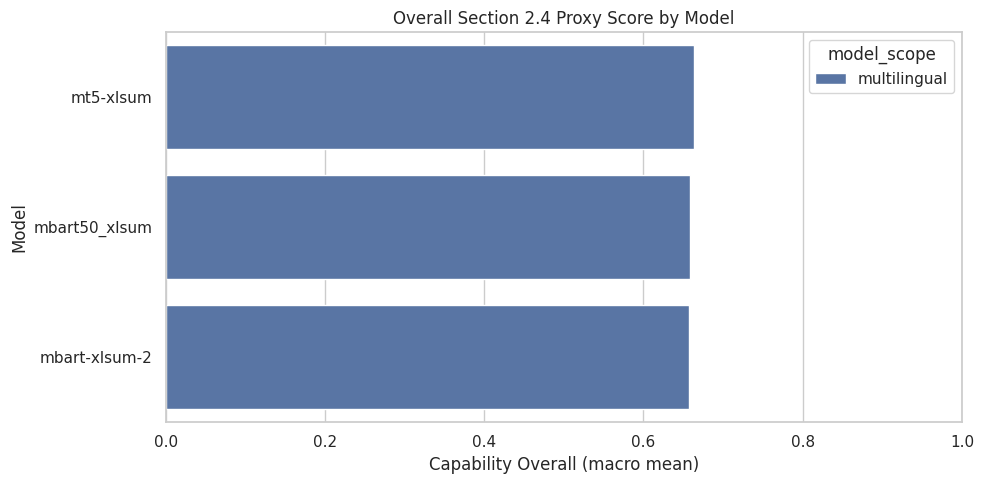

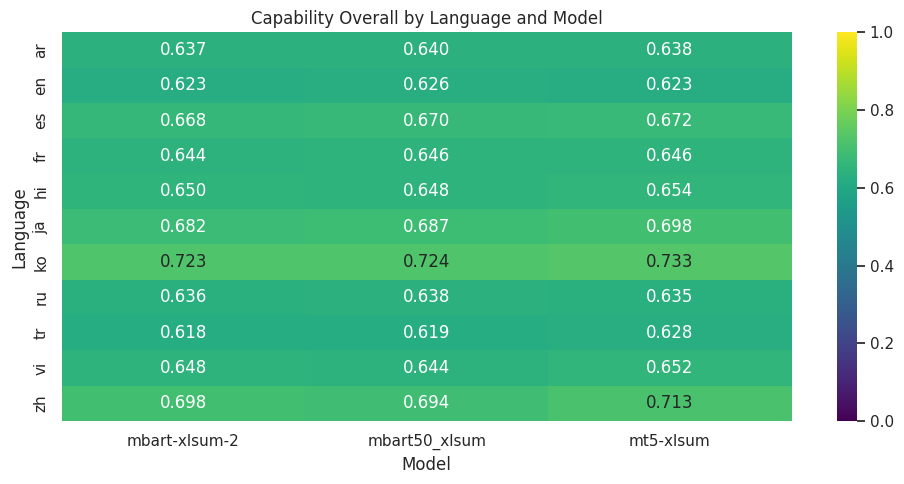

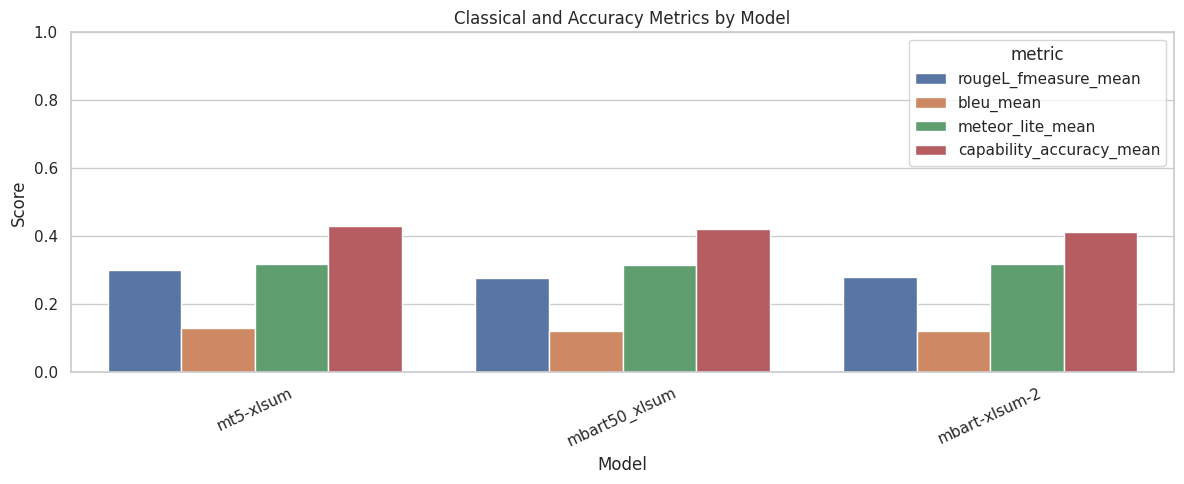

Plot files:
/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051/overall_capability_by_model.png
/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051/language_model_capability_heatmap.png
/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051/classical_metrics_by_model.png


In [ ]:
# =========================================================
# PLOTS
# =========================================================

plot_paths = []
if plt is not None and sns is not None:
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = overall_summary_df.sort_values("capability_overall_mean", ascending=False)
    sns.barplot(data=plot_df, x="capability_overall_mean", y="model", hue="model_scope", dodge=False, ax=ax)
    ax.set_title("Overall Section 2.4 Proxy Score by Model")
    ax.set_xlabel("Capability Overall (macro mean)")
    ax.set_ylabel("Model")
    ax.set_xlim(0, 1)
    fig.tight_layout()
    p = RUN_DIR / "overall_capability_by_model.png"
    fig.savefig(p, dpi=180)
    plot_paths.append(p)
    plt.show()

    heat_df = lang_summary_df.pivot_table(index="language", columns="model", values="capability_overall_mean")
    if not heat_df.empty:
        fig, ax = plt.subplots(figsize=(max(10, 1.6 * len(heat_df.columns)), max(5, 0.45 * len(heat_df.index))))
        sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="viridis", vmin=0, vmax=1, ax=ax)
        ax.set_title("Capability Overall by Language and Model")
        ax.set_xlabel("Model")
        ax.set_ylabel("Language")
        fig.tight_layout()
        p = RUN_DIR / "language_model_capability_heatmap.png"
        fig.savefig(p, dpi=180)
        plot_paths.append(p)
        plt.show()

    metric_plot_cols = ["rougeL_fmeasure_mean", "bleu_mean", "meteor_lite_mean", "capability_accuracy_mean"]
    available_metric_plot_cols = [c for c in metric_plot_cols if c in overall_summary_df.columns]
    if available_metric_plot_cols:
        melted = overall_summary_df.melt(
            id_vars=["model", "model_scope"],
            value_vars=available_metric_plot_cols,
            var_name="metric",
            value_name="score",
        )
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=melted, x="model", y="score", hue="metric", ax=ax)
        ax.set_title("Classical and Accuracy Metrics by Model")
        ax.set_xlabel("Model")
        ax.set_ylabel("Score")
        ax.set_ylim(0, max(1.0, float(melted["score"].max()) * 1.15))
        ax.tick_params(axis="x", rotation=25)
        fig.tight_layout()
        p = RUN_DIR / "classical_metrics_by_model.png"
        fig.savefig(p, dpi=180)
        plot_paths.append(p)
        plt.show()

print("Plot files:")
for p in plot_paths:
    print(p)

In [ ]:
# =========================================================
# MARKDOWN REPORT
# =========================================================

def fmt(value: Any, digits: int = 4) -> str:
    if value is None or pd.isna(value):
        return "-"
    if isinstance(value, (int, np.integer)):
        return str(value)
    if isinstance(value, (float, np.floating)):
        return f"{float(value):.{digits}f}"
    return str(value)


def markdown_table(df: pd.DataFrame, cols: List[str], max_rows: int = 30) -> str:
    subset = df.loc[:, [c for c in cols if c in df.columns]].head(max_rows).copy()
    if subset.empty:
        return ""
    lines = []
    lines.append("| " + " | ".join(subset.columns) + " |")
    lines.append("|" + "|".join(["---" for _ in subset.columns]) + "|")
    for _, row in subset.iterrows():
        lines.append("| " + " | ".join(fmt(row[c]) for c in subset.columns) + " |")
    return "\n".join(lines)

skipped_df = language_plan_df[language_plan_df["status"] != "run"]
report_lines = [
    "# XL-Sum Evaluation Report",
    "",
    f"Generated at: `{config_payload['created_at']}`",
    f"Run directory: `{RUN_DIR}`",
    f"Dataset: `csebuetnlp/xlsum`, split: `{XLSUM_SPLIT}`",
    f"Device: `{DEVICE}`",
    f"Max samples per language: `{MAX_SAMPLES_PER_LANG}`",
    "",
    "## Overall Model Macro Summary",
    "",
    markdown_table(
        overall_summary_df,
        ["model", "model_scope", "languages", "samples", "capability_overall_mean", "capability_coherence_mean", "capability_accuracy_mean", "capability_clarity_mean", "capability_relevance_mean", "capability_efficiency_mean", "rougeL_fmeasure_mean", "bleu_mean", "meteor_lite_mean", "latency_seconds_mean"],
    ),
    "",
    "## Language / Model Summary",
    "",
    markdown_table(
        lang_summary_df,
        ["language", "xlsum_subset", "model", "samples", "capability_overall_mean", "rouge1_fmeasure_mean", "rouge2_fmeasure_mean", "rougeL_fmeasure_mean", "bleu_mean", "meteor_lite_mean"],
        max_rows=80,
    ),
    "",
    "## Skipped Languages",
    "",
    skipped_df.to_markdown(index=False) if not skipped_df.empty else "No selected languages were skipped.",
    "",
    "## Metric Formulas",
    "",
    metric_definitions_df.to_markdown(index=False),
    "",
    "## Notes",
    "",
    "- Section 2.4 scores are automatic proxies, not human annotation.",
    "- `accuracy` combines gold-summary overlap and source grounding; it does not prove factual truth by itself.",
    "- `efficiency` depends on current Colab hardware load, batch size, and generation settings.",
    "- German, Italian, Dutch, and Romanian are kept in the selected 15-language plan, but the public `csebuetnlp/xlsum` release does not provide matching subsets; use a local held-out eval file for those if needed.",
]

report_md = RUN_DIR / "report.md"
report_md.write_text("\n".join(report_lines), encoding="utf-8")
print(report_md)
print("\n".join(report_lines[:30]))

/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051/report.md
# XL-Sum Evaluation Report

Generated at: `2026-05-09T18:09:20.077299`
Run directory: `/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051`
Dataset: `csebuetnlp/xlsum`, split: `test`
Device: `cuda`
Max samples per language: `None`

## Overall Model Macro Summary

| model | model_scope | languages | samples | capability_overall_mean | capability_coherence_mean | capability_accuracy_mean | capability_clarity_mean | capability_relevance_mean | capability_efficiency_mean | rougeL_fmeasure_mean | bleu_mean | meteor_lite_mean | latency_seconds_mean |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| mt5-xlsum | multilingual | 11 | 52219 | 0.6631 | 0.9750 | 0.4301 | 0.9180 | 0.2662 | 0.7260 | 0.3010 | 0.1310 | 0.3195 | 0.2552 |
| mbart50_xlsum | multilingual | 11 | 52219 | 0.6578 | 0.9622 | 0.4211 | 0.8926 | 0.2701 | 0.7431 | 0.2785 | 0.1202 | 0

In [ ]:
# Optional: ZIP all report artifacts for transfer/sharing.
import shutil
zip_base = RUN_DIR.parent / RUN_NAME
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=str(RUN_DIR))
print(zip_path)

/content/drive/MyDrive/inf494_projet/evaluation/xlsum_eval_runs/xlsum_eval_20260509_091051.zip
